In [7]:
import os
import pandas as pd
import tables
import numpy as np
from utils import *
import matplotlib.pyplot as plt
import pysam
from plotnine import *
from scipy.stats import spearmanr
import patchworklib as pw

font_size = 30

#Merges consecutive peaks
def mergeBed(x): 
    
    #This works because peaks are non-overlapping
    #we first stack, then remove duplicates and unstack
    stacked = x.set_index('peak_chrom').stack().droplevel(-1).rename("peak_start")
    output = stacked.reset_index().drop_duplicates(keep=False).set_index("peak_chrom")
    output["peak_end"] = output["peak_start"].shift(-1)
    output = output.iloc[range(0, len(output.index), 2)]
    
    return output
    
#Set working directory
working_dir ="TF_Positional_Distribution_Model/data/ENCODE/K562/EPI"
os.chdir(working_dir)


training_K562 = pd.read_hdf('training.h5', 'training').set_index(['enhancer_name', 'promoter_name'])
training_K562 = training_K562.loc[training_K562.label == 1]


named_promoters = pd.read_table('K562_EnhancerAssociatedPromoters_named.bed',
                              names = ['chrom','start','end','Gene',  'promoter_chrom',
                                      'promoter_start','promoter_end'])
named_promoters['TSS'] = (named_promoters.end + named_promoters.start) /2

#Only consider promoters within 10kb of an annotated gene
training_K562 = training_K562.merge(named_promoters, on = ['promoter_chrom','promoter_start','promoter_end'],
                   how = 'inner')

#Read exponential fit parameters
params = pd.read_csv('../../processed/ExpDecayConst_params.csv', index_col = 0)
params = params.loc[params.CellLine =='K562']

os.chdir('intersections')
files = os.listdir()
files = [f for f in files if 'promoters.bed' in f]




In [10]:
compiled_EPpairs = pd.DataFrame()

#Get EP pairs for each TF
for file in files:
    
    #Get list of accessible bound promoters
    bound_promoters = pd.read_table(file,header = None)
    named_promoters = pd.read_table('../../ChIP-seq/' + 
                                    file.replace('_intersection_promoters','_named'), 
                                   names = ['peak_chrom','peak_start', 'peak_end', 'Gene'])
    
    #Select peaks that are accessible and have atleast 1 binding event
    n_cols = len(bound_promoters.columns)
    chip_columns = ['rep' + str(i+1) for i in range(n_cols-9)]

    bound_promoters.columns = ['peak_chrom', 'peak_start', 'peak_end', 'num','list'] + chip_columns + ['atac','promoter_chrom', 'promoter_start', 'promoter_end' ]
    bound_promoters = bound_promoters.loc[bound_promoters.atac ==1]
    bound_promoters = bound_promoters.loc[bound_promoters[chip_columns].sum(axis =1)>1]
    bound_promoters = bound_promoters[['peak_chrom', 'peak_start', 'peak_end', 'num','promoter_chrom', 'promoter_start', 'promoter_end' ]]
    bound_promoters = bound_promoters.merge(named_promoters)
    bound_promoters = bound_promoters.groupby(['promoter_chrom','promoter_start', 'promoter_end','Gene']).apply(lambda x: mergeBed(x[['peak_chrom','peak_start','peak_end']])).reset_index()
    bound_promoters.columns =['promoter_' + i if 'promoter' not in i else i for i in bound_promoters.columns]

    #Get list of accessible bound enhancers
    bound_enhancers = pd.read_table(file.replace('promoter','enhancer'),header = None)
    n_cols = len(bound_enhancers.columns)
    chip_columns = ['rep' + str(i+1) for i in range(n_cols-9)]

    bound_enhancers.columns = ['peak_chrom', 'peak_start', 'peak_end', 'num','list'] + chip_columns + ['atac','enhancer_chrom', 'enhancer_start', 'enhancer_end' ]
    bound_enhancers = bound_enhancers.loc[bound_enhancers.atac ==1]
    bound_enhancers = bound_enhancers.loc[bound_enhancers[chip_columns].sum(axis =1)>1]
    bound_enhancers = bound_enhancers[['peak_chrom', 'peak_start', 'peak_end', 'num','enhancer_chrom', 'enhancer_start', 'enhancer_end' ]]
    bound_enhancers = bound_enhancers.groupby(['enhancer_chrom','enhancer_start', 'enhancer_end']).apply(lambda x: mergeBed(x[['peak_chrom','peak_start','peak_end']])).reset_index()
    bound_enhancers.columns =['enhancer_' + i if 'enhancer' not in i else i for i in bound_enhancers.columns]
    
    #Get EP pairs
    bound_promoters= training_K562.merge(bound_promoters, 
                                     on = ['promoter_chrom','promoter_start','promoter_end'],
                                     how = 'outer',
                                     indicator = 'promoter_bound')
    bound_enhancers= training_K562.merge(bound_enhancers, 
                                     on = ['enhancer_chrom','enhancer_start','enhancer_end'],
                                     how = 'left',
                                     indicator = 'enhancer_bound')
    EPpairs = bound_promoters.merge(bound_enhancers,
                                    how = 'outer')
    
    #Get parameters for TF
    tf = file.split('_')[0]
    params_tf = params.loc[params.TF==tf]

    if EPpairs.shape[0] >0:

        EPpairs['TF'] = tf
        
        ### For enhancer/neither, set promoter start/end as specified
        EPpairs.loc[EPpairs.promoter_peak_start.isna(),'promoter_peak_start'] = EPpairs['promoter_start'].loc[EPpairs.promoter_peak_start.isna()]
        EPpairs.loc[EPpairs.promoter_peak_end.isna(),'promoter_peak_end'] = EPpairs['promoter_end'].loc[EPpairs.promoter_peak_end.isna()]

        ## Calculate distance to promoter
        EPpairs['Distance_TSS'] = abs(EPpairs['TSS'] - 
                                      ((EPpairs['promoter_peak_start'] + 
                                        EPpairs['promoter_peak_end'])/2 ))

        #Estimate threshold based on model
        threshold =  n_max_true(params_tf.rb.values[0] , 
                                params_tf.tau.values[0] ,
                                params_tf.rs.values[0],
                                [0.1]).Distance[0]

        #Classify promoters
        EPpairs['Binding'] = EPpairs['Distance_TSS'] <= threshold
        EPpairs['Binding_2kb'] = EPpairs['Distance_TSS'] <= 2000
        #Compile results 
        compiled_EPpairs = pd.concat([compiled_EPpairs, EPpairs])



In [12]:
### Annotate binding sites
compiled_EPpairs['Class'] ='Neither'
compiled_EPpairs['Class'].loc[(compiled_EPpairs['enhancer_bound'] == 'left_only') &
                    (compiled_EPpairs['promoter_bound'] == 'both')] = 'Promoter only'
compiled_EPpairs['Class'].loc[(compiled_EPpairs['enhancer_bound'] == 'both') &
                    (compiled_EPpairs['promoter_bound'] == 'both')] = 'EP bound'
compiled_EPpairs['Class'].loc[(compiled_EPpairs['enhancer_bound'] == 'both') &
                    (compiled_EPpairs['promoter_bound'] == 'left_only')] = 'Enhancer only'

/home/mpf1405/.conda/envs/jupyter-kernel-py37/lib/python3.7/site-packages/pandas/core/indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


### RNA-seq data

In [48]:
font_size = 30
compiled_rna = pd.read_csv('../../../RNA-seq/Compiled_RNAseq.csv', index_col = 0)
expression_groups = compiled_EPpairs[['TF','Gene','Class','Binding']].merge(compiled_rna,
                                                                 how = 'inner').drop_duplicates() 

expression_long = pd.melt(expression_groups.groupby(['TF','Gene','Class'])[compiled_rna.columns[1:]].mean().reset_index(),
       id_vars = ['TF','Gene','Class'])
expression_long_mean = expression_long.groupby(['TF','Class']).agg({'value':'median'}).reset_index()
expression_long_mean.Class = pd.Categorical(expression_long_mean.Class, 
                                           ['Neither','Enhancer only','Promoter only', 'EP bound'])

fig6A = (ggplot(expression_long_mean)
 +geom_boxplot(aes(x= 'Class', y = 'value'))
 +geom_line(aes(x= 'Class', y = 'value+0.0001',group = 'TF'), alpha = 0.1)
 +geom_point(aes(x= 'Class', y = 'value+0.0001'))
 +xlab('')
 +ylab('Median mRNA counts')
 +theme(text = element_text(size = 18))
#+facet_wrap('TF')
 +scale_y_log10()
)

In [49]:
expression_groups_promoterbound = expression_groups.loc[expression_groups.Class.isin(['EP bound', 'Promoter only'])]
expression_groups_promoterbound['Binding_any'] = expression_groups_promoterbound.groupby('Gene')['Binding'].transform(any)
expression_groups_promoterbound = expression_groups_promoterbound .loc[expression_groups_promoterbound.Binding == expression_groups_promoterbound.Binding_any]
expression_groups_promoterbound_long = pd.melt(expression_groups_promoterbound.groupby(['TF','Gene','Binding','Class'])[compiled_rna.columns[1:]].mean().reset_index(),
       id_vars = ['TF','Gene','Binding','Class'])
expression_groups_promoterbound_long_mean = expression_groups_promoterbound_long.groupby(['TF','Gene','Class','Binding']).agg({'value':'median'}).reset_index()


fig6B = (ggplot(expression_groups_promoterbound_long_mean)
 +geom_boxplot(aes(x= 'Class', y = 'value+0.0001', fill = 'Binding'))
 +geom_jitter(aes(x= 'Class', y = 'value+0.0001', fill = 'Binding'),position=position_dodge(width=0.75))
 +scale_y_log10()
  +xlab('')
 +ylab('Median mRNA counts')
 +scale_fill_manual(values = ['purple','green'])
  +theme(text = element_text(size = font_size))
)

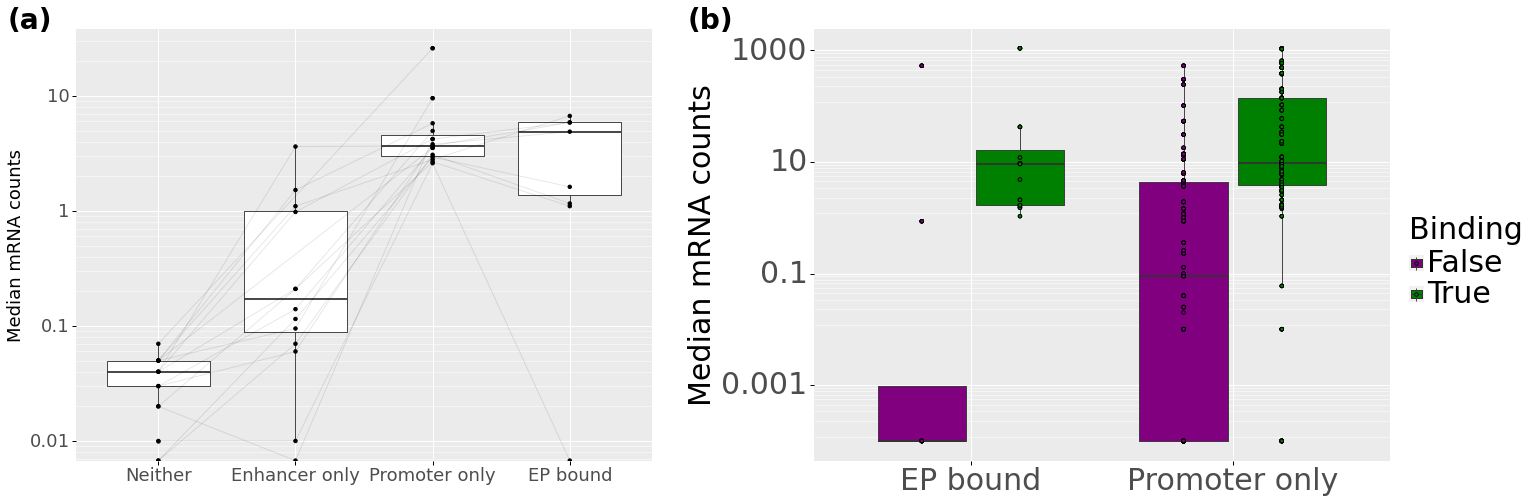

In [50]:

fig6A = pw.load_ggplot(fig6A, figsize = (8,6))
fig6B = pw.load_ggplot(fig6B, figsize = (8,6))

fig6A.set_index('(a)',size = 28,fontweight="bold")
fig6B.set_index('(b)',size = 28,fontweight="bold")


fig6 = (fig6A + fig6B)
fig6.savefig('../../../../../Figures/Figure6.pdf')